# 01 — Data Fetching Validation
**Purpose:** Test the `DataFetcher` module across both supported data sources.

| Source | Login required | 4H support | Intraday history |
|---|---|---|---|
| `yfinance` | No | Resampled from 1H | ~60 days for 15m/30m |
| `tradingview` | Optional | **Native** | Up to 5000 bars |

**Checklist:**
- [ ] yfinance — all 3 timeframes fetch without errors
- [ ] yfinance — `multi_level_index=False` produces flat columns
- [ ] yfinance — 4H correctly resampled from 1H
- [ ] TradingView — all 3 timeframes fetch without errors
- [ ] TradingView — native 4H matches yfinance resampled 4H closely
- [ ] Both sources — OHLCV schema, no NaNs, no zero prices
- [ ] Cache CSVs written to `data/raw/` with source suffix

---
## 0. Setup

In [1]:
# Install dependencies if needed (run once)
# !pip install yfinance pandas matplotlib
# !pip install git+https://github.com/rongardF/tvdatafeed.git

In [1]:
import sys
import logging
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Point Python at the project root
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

print(f"Project root : {PROJECT_ROOT}")

Project root : D:\Projects\Madstat\madstrat_backtest


In [2]:
import importlib
_fetcher_module = importlib.import_module("src.data.fetcher")
importlib.reload(_fetcher_module)
from src.data.fetcher import DataFetcher
print("DataFetcher imported successfully ✓")

DataFetcher imported successfully ✓


---
## 1. Configuration

In [3]:
INSTRUMENT = "EURUSD"
START_DATE = "2026-03-26"
END_DATE   = "2026-04-26"
TIMEFRAMES = ["15m", "1h", "4h"]

# TradingView credentials (leave blank to test no-login mode)
TV_USERNAME = ""   # e.g. "your_tv_username"
TV_PASSWORD = ""   # e.g. "your_tv_password"

print(f"Instrument : {INSTRUMENT}")
print(f"Period     : {START_DATE} → {END_DATE}")
print(f"Timeframes : {TIMEFRAMES}")
print(f"TV Login   : {'Yes' if TV_USERNAME else 'No (no-login mode)'}")

Instrument : EURUSD
Period     : 2026-03-26 → 2026-04-26
Timeframes : ['15m', '1h', '4h']
TV Login   : No (no-login mode)


---
## 2. Shared Quality Check Helper
Defined once and reused for both sources.

In [4]:
def quality_report(data: dict, label: str):
    """Print a quality summary table for a dict of {tf: DataFrame}."""
    print(f"\n{'='*70}")
    print(f" Quality Report — {label}")
    print(f"{'='*70}")
    print(f"{'TF':<8} {'Bars':<8} {'Start':<24} {'End':<24} "
          f"{'NaN':<6} {'Zeros':<7} {'BadHL':<7}")
    print("-" * 90)

    all_clean = True
    for tf, df in data.items():
        nan_count  = df[["open","high","low","close"]].isnull().sum().sum()
        zero_count = len(df[(df["open"] == 0) | (df["close"] == 0)])
        badhl      = len(df[df["high"] < df["low"]])
        flag       = "❌" if any([nan_count, zero_count, badhl]) else "✓ "
        if any([nan_count, zero_count, badhl]):
            all_clean = False
        print(
            f"{flag} {tf:<6} {len(df):<8} "
            f"{str(df.index[0]):<24} {str(df.index[-1]):<24} "
            f"{nan_count:<6} {zero_count:<7} {badhl}"
        )

    print()
    if all_clean:
        print(f"  ✅ All quality checks passed for {label}")
    else:
        print(f"  ⚠️  Issues found in {label} — review above")
    return all_clean


def schema_check(data: dict, label: str):
    """Verify columns and dtypes match the expected Madstrat schema."""
    REQUIRED = ["open", "high", "low", "close", "volume"]
    print(f"\n Schema check — {label}")
    for tf, df in data.items():
        missing = [c for c in REQUIRED if c not in df.columns]
        extra   = [c for c in df.columns if c not in REQUIRED]
        idx_ok  = isinstance(df.index, pd.DatetimeIndex)
        status  = "✓" if (not missing and idx_ok) else "❌"
        print(f"  {status} [{tf}]  columns={list(df.columns)}  "
              f"DatetimeIndex={idx_ok}  missing={missing}  extra={extra}")

---
## 3. Source A — yfinance
### 3.1 Fetch data

In [5]:
yf_fetcher = DataFetcher(
    instrument=INSTRUMENT,
    start=START_DATE,
    end=END_DATE,
    source="yfinance",
    save_raw=True,
)

yf_data = yf_fetcher.fetch_all(TIMEFRAMES)

print("\nyfinance download summary:")
for tf, df in yf_data.items():
    print(f"  [{tf}]  {len(df):>5} bars  |  {df.index[0]}  →  {df.index[-1]}")

2026-04-26 02:25:10,163 | INFO | DataFetcher ready — EURUSD | 2026-03-26 → 2026-04-26 | source=yfinance
2026-04-26 02:25:10,182 | INFO | [EURUSD] Fetching [15m] via yfinance...
2026-04-26 02:25:34,638 | INFO | [EURUSD][15m] Downloading from yfinance (ticker=EURUSD=X, interval=15m)...
2026-04-26 02:26:34,680 | INFO | [EURUSD][15m] 2063 bars downloaded | 2026-03-26 00:00:00+00:00 → 2026-04-24 21:15:00+00:00
2026-04-26 02:26:35,976 | INFO | Cached → EURUSD_15m_2026-03-26_2026-04-26_yfinance.csv
2026-04-26 02:26:35,992 | INFO | [EURUSD] Fetching [1h] via yfinance...
2026-04-26 02:26:36,010 | INFO | [EURUSD][1h] Downloading from yfinance (ticker=EURUSD=X, interval=1h)...
2026-04-26 02:26:37,710 | INFO | [EURUSD][1h] 520 bars downloaded | 2026-03-26 00:00:00+00:00 → 2026-04-24 21:00:00+00:00
2026-04-26 02:26:37,888 | INFO | Cached → EURUSD_1h_2026-03-26_2026-04-26_yfinance.csv
2026-04-26 02:26:37,904 | INFO | [EURUSD] Fetching [4h] via yfinance...
2026-04-26 02:26:37,916 | INFO | [EURUSD][4h


yfinance download summary:
  [15m]   2063 bars  |  2026-03-26 00:00:00+00:00  →  2026-04-24 21:15:00+00:00
  [1h]    520 bars  |  2026-03-26 00:00:00+00:00  →  2026-04-24 21:00:00+00:00
  [4h]    125 bars  |  2026-03-26 00:00:00+00:00  →  2026-04-24 16:00:00+00:00


### 3.2 Schema & quality

In [6]:
schema_check(yf_data, "yfinance")
yf_clean = quality_report(yf_data, "yfinance")


 Schema check — yfinance
  ✓ [15m]  columns=['open', 'high', 'low', 'close', 'volume']  DatetimeIndex=True  missing=[]  extra=[]
  ✓ [1h]  columns=['open', 'high', 'low', 'close', 'volume']  DatetimeIndex=True  missing=[]  extra=[]
  ✓ [4h]  columns=['open', 'high', 'low', 'close', 'volume']  DatetimeIndex=True  missing=[]  extra=[]

 Quality Report — yfinance
TF       Bars     Start                    End                      NaN    Zeros   BadHL  
------------------------------------------------------------------------------------------
✓  15m    2063     2026-03-26 00:00:00+00:00 2026-04-24 21:15:00+00:00 0      0       0
✓  1h     520      2026-03-26 00:00:00+00:00 2026-04-24 21:00:00+00:00 0      0       0
✓  4h     125      2026-03-26 00:00:00+00:00 2026-04-24 16:00:00+00:00 0      0       0

  ✅ All quality checks passed for yfinance


### 3.3 Verify `multi_level_index=False` — columns must be flat

In [7]:
# With multi_level_index=False yfinance returns a flat Index, not a MultiIndex.
# After our _clean_yf() step the columns should be exactly:
#   ['open', 'high', 'low', 'close', 'volume']

print("Flat column check (multi_level_index=False):")
for tf, df in yf_data.items():
    is_multi = isinstance(df.columns, pd.MultiIndex)
    cols     = list(df.columns)
    ok       = not is_multi and cols == ["open", "high", "low", "close", "volume"]
    print(f"  {'✓' if ok else '❌'} [{tf}]  MultiIndex={is_multi}  columns={cols}")

Flat column check (multi_level_index=False):
  ✓ [15m]  MultiIndex=False  columns=['open', 'high', 'low', 'close', 'volume']
  ✓ [1h]  MultiIndex=False  columns=['open', 'high', 'low', 'close', 'volume']
  ✓ [4h]  MultiIndex=False  columns=['open', 'high', 'low', 'close', 'volume']


### 3.4 Verify 4H resampling from 1H

In [8]:
df_1h = yf_data["1h"]
df_4h = yf_data["4h"]

print(f"1H bars : {len(df_1h)}")
print(f"4H bars : {len(df_4h)}")
print(f"Ratio   : {len(df_1h) / len(df_4h):.2f}  (expect ~4.0)")

# Sample 3 random 4H bars and validate against constituent 1H bars
sample = df_4h.sample(3, random_state=42).sort_index()
print("\nManual alignment check (3 random 4H bars):")
print("-" * 65)

all_ok = True
for ts, row in sample.iterrows():
    window = df_1h[ts : ts + pd.Timedelta(hours=3)]
    if window.empty:
        print(f"  {ts} | No 1H window found")
        continue

    exp_o = window.iloc[0]["open"]
    exp_c = window.iloc[-1]["close"]
    exp_h = window["high"].max()
    exp_l = window["low"].min()

    ok = all([
        abs(row["open"]  - exp_o) < 1e-6,
        abs(row["close"] - exp_c) < 1e-6,
        abs(row["high"]  - exp_h) < 1e-6,
        abs(row["low"]   - exp_l) < 1e-6,
    ])
    if not ok:
        all_ok = False

    icon = "✓" if ok else "❌"
    print(f"  {icon} {ts}")
    print(f"      4H  O:{row['open']:.5f}  H:{row['high']:.5f}  "
          f"L:{row['low']:.5f}  C:{row['close']:.5f}")
    print(f"      1H* O:{exp_o:.5f}  H:{exp_h:.5f}  "
          f"L:{exp_l:.5f}  C:{exp_c:.5f}  ({len(window)} bars)")

print()
print("✅ 4H resampling correct" if all_ok else "❌ Resampling mismatch — check fetcher._resample_to_4h()")

1H bars : 520
4H bars : 125
Ratio   : 4.16  (expect ~4.0)

Manual alignment check (3 random 4H bars):
-----------------------------------------------------------------
  ✓ 2026-03-31 04:00:00+00:00
      4H  O:1.14732  H:1.14771  L:1.14639  C:1.14758
      1H* O:1.14732  H:1.14771  L:1.14639  C:1.14758  (4 bars)
  ✓ 2026-04-03 04:00:00+00:00
      4H  O:1.15393  H:1.15500  L:1.15327  C:1.15460
      1H* O:1.15393  H:1.15500  L:1.15327  C:1.15460  (4 bars)
  ✓ 2026-04-06 08:00:00+00:00
      4H  O:1.15701  H:1.15701  L:1.15447  C:1.15487
      1H* O:1.15701  H:1.15701  L:1.15447  C:1.15487  (4 bars)

✅ 4H resampling correct


### 3.5 Sample preview

In [9]:
for tf, df in yf_data.items():
    print(f"\n── yfinance {tf} | head ──────────────────────────────")
    display(df.head(3))


── yfinance 15m | head ──────────────────────────────


,open,high,low,close,volume
Datetime,,,,,
2026-03-26 00:00:00+00:00,1.156604,1.156738,1.156470,1.156738,0
2026-03-26 00:15:00+00:00,1.156604,1.156738,1.156337,1.156337,0
2026-03-26 00:30:00+00:00,1.156470,1.156470,1.155936,1.155936,0



── yfinance 1h | head ──────────────────────────────


,open,high,low,close,volume
Datetime,,,,,
2026-03-26 00:00:00+00:00,1.156604,1.156738,1.155802,1.156203,0
2026-03-26 01:00:00+00:00,1.156470,1.157006,1.156470,1.156738,0
2026-03-26 02:00:00+00:00,1.156738,1.156872,1.155936,1.156203,0



── yfinance 4h | head ──────────────────────────────


,open,high,low,close,volume
Datetime,,,,,
2026-03-26 00:00:00+00:00,1.156604,1.157274,1.155802,1.157140,0
2026-03-26 04:00:00+00:00,1.157140,1.157541,1.155535,1.155668,0
2026-03-26 08:00:00+00:00,1.155402,1.156738,1.152738,1.152738,0


---
## 4. Source B — TradingView
### 4.1 Fetch data

In [10]:
tv_fetcher = DataFetcher(
    instrument=INSTRUMENT,
    start=START_DATE,
    end=END_DATE,
    source="tradingview",
    tv_username=TV_USERNAME or None,
    tv_password=TV_PASSWORD or None,
    save_raw=True,
)

tv_data = tv_fetcher.fetch_all(TIMEFRAMES)

print("\nTradingView download summary:")
for tf, df in tv_data.items():
    print(f"  [{tf}]  {len(df):>5} bars  |  {df.index[0]}  →  {df.index[-1]}")

2026-04-26 02:27:35,365 | INFO | DataFetcher ready — EURUSD | 2026-03-26 → 2026-04-26 | source=tradingview
2026-04-26 02:27:35,377 | INFO | [EURUSD] Fetching [15m] via tradingview...
2026-04-26 02:27:35,664 | WARNING | Connecting to TradingView without login — some symbols may be unavailable. Pass tv_username and tv_password for full access.
2026-04-26 02:27:35,677 | WARNING | you are using nologin method, data you access may be limited
2026-04-26 02:27:35,692 | INFO | [EURUSD][15m] Downloading from TradingView (symbol=EURUSD, exchange=FX, n_bars=2338)...


2026-04-26 02:27:39,700 | INFO | [EURUSD][15m] 2120 bars downloaded | 2026-03-26 00:00:00 → 2026-04-25 01:45:00
2026-04-26 02:27:39,929 | INFO | Cached → EURUSD_15m_2026-03-26_2026-04-26_tradingview.csv
2026-04-26 02:27:39,942 | INFO | [EURUSD] Fetching [1h] via tradingview...
2026-04-26 02:27:39,956 | INFO | [EURUSD][1h] Downloading from TradingView (symbol=EURUSD, exchange=FX, n_bars=584)...
2026-04-26 02:27:42,391 | INFO | [EURUSD][1h] 530 bars downloaded | 2026-03-26 00:00:00 → 2026-04-25 01:00:00
2026-04-26 02:27:42,470 | INFO | Cached → EURUSD_1h_2026-03-26_2026-04-26_tradingview.csv
2026-04-26 02:27:42,485 | INFO | [EURUSD] Fetching [4h] via tradingview...
2026-04-26 02:27:42,503 | INFO | [EURUSD][4h] Downloading from TradingView (symbol=EURUSD, exchange=FX, n_bars=146)...
2026-04-26 02:27:44,608 | INFO | [EURUSD][4h] 132 bars downloaded | 2026-03-26 02:00:00 → 2026-04-24 22:00:00
2026-04-26 02:27:44,644 | INFO | Cached → EURUSD_4h_2026-03-26_2026-04-26_tradingview.csv



TradingView download summary:
  [15m]   2120 bars  |  2026-03-26 00:00:00  →  2026-04-25 01:45:00
  [1h]    530 bars  |  2026-03-26 00:00:00  →  2026-04-25 01:00:00
  [4h]    132 bars  |  2026-03-26 02:00:00  →  2026-04-24 22:00:00


### 4.2 Schema & quality

In [11]:
schema_check(tv_data, "tradingview")
tv_clean = quality_report(tv_data, "tradingview")


 Schema check — tradingview
  ✓ [15m]  columns=['open', 'high', 'low', 'close', 'volume']  DatetimeIndex=True  missing=[]  extra=[]
  ✓ [1h]  columns=['open', 'high', 'low', 'close', 'volume']  DatetimeIndex=True  missing=[]  extra=[]
  ✓ [4h]  columns=['open', 'high', 'low', 'close', 'volume']  DatetimeIndex=True  missing=[]  extra=[]

 Quality Report — tradingview
TF       Bars     Start                    End                      NaN    Zeros   BadHL  
------------------------------------------------------------------------------------------
✓  15m    2120     2026-03-26 00:00:00      2026-04-25 01:45:00      0      0       0
✓  1h     530      2026-03-26 00:00:00      2026-04-25 01:00:00      0      0       0
✓  4h     132      2026-03-26 02:00:00      2026-04-24 22:00:00      0      0       0

  ✅ All quality checks passed for tradingview


### 4.3 Confirm 4H is native (no resampling)
TradingView returns 4H directly — the bar count should be very close to the
yfinance resampled 4H. Large discrepancies indicate an alignment issue.

In [12]:
tv_4h = tv_data["4h"]
yf_4h = yf_data["4h"]

print("4H bar count comparison:")
print(f"  TradingView (native) : {len(tv_4h)} bars")
print(f"  yfinance (resampled) : {len(yf_4h)} bars")
print(f"  Difference           : {abs(len(tv_4h) - len(yf_4h))} bars")

# A small difference (< 5%) is acceptable due to session/holiday differences
pct_diff = abs(len(tv_4h) - len(yf_4h)) / max(len(yf_4h), 1) * 100
ok = pct_diff < 5
print(f"  % difference         : {pct_diff:.1f}%  {'✓ within 5%' if ok else '⚠️  exceeds 5%'}")

4H bar count comparison:
  TradingView (native) : 132 bars
  yfinance (resampled) : 125 bars
  Difference           : 7 bars
  % difference         : 5.6%  ⚠️  exceeds 5%


### 4.4 Sample preview

In [13]:
for tf, df in tv_data.items():
    print(f"\n── TradingView {tf} | head ───────────────────────────")
    display(df.head(3))


── TradingView 15m | head ───────────────────────────


,open,high,low,close,volume
datetime,,,,,
2026-03-26 00:00:00,1.15664,1.15664,1.15590,1.15606,2502.0
2026-03-26 00:15:00,1.15606,1.15660,1.15604,1.15631,2093.0
2026-03-26 00:30:00,1.15631,1.15665,1.15615,1.15646,1742.0



── TradingView 1h | head ───────────────────────────


,open,high,low,close,volume
datetime,,,,,
2026-03-26 00:00:00,1.15664,1.15665,1.15590,1.15632,8460.0
2026-03-26 01:00:00,1.15632,1.15635,1.15560,1.15586,3051.0
2026-03-26 02:00:00,1.15586,1.15610,1.15568,1.15593,854.0



── TradingView 4h | head ───────────────────────────


,open,high,low,close,volume
datetime,,,,,
2026-03-26 02:00:00,1.15586,1.15646,1.15540,1.15581,10358.0
2026-03-26 06:00:00,1.15581,1.15723,1.15547,1.15693,15149.0
2026-03-26 10:00:00,1.15693,1.15698,1.15473,1.15597,29131.0


---
## 5. Side-by-Side Close Price Comparison
Plot yfinance vs TradingView on the same chart to spot any major divergences.

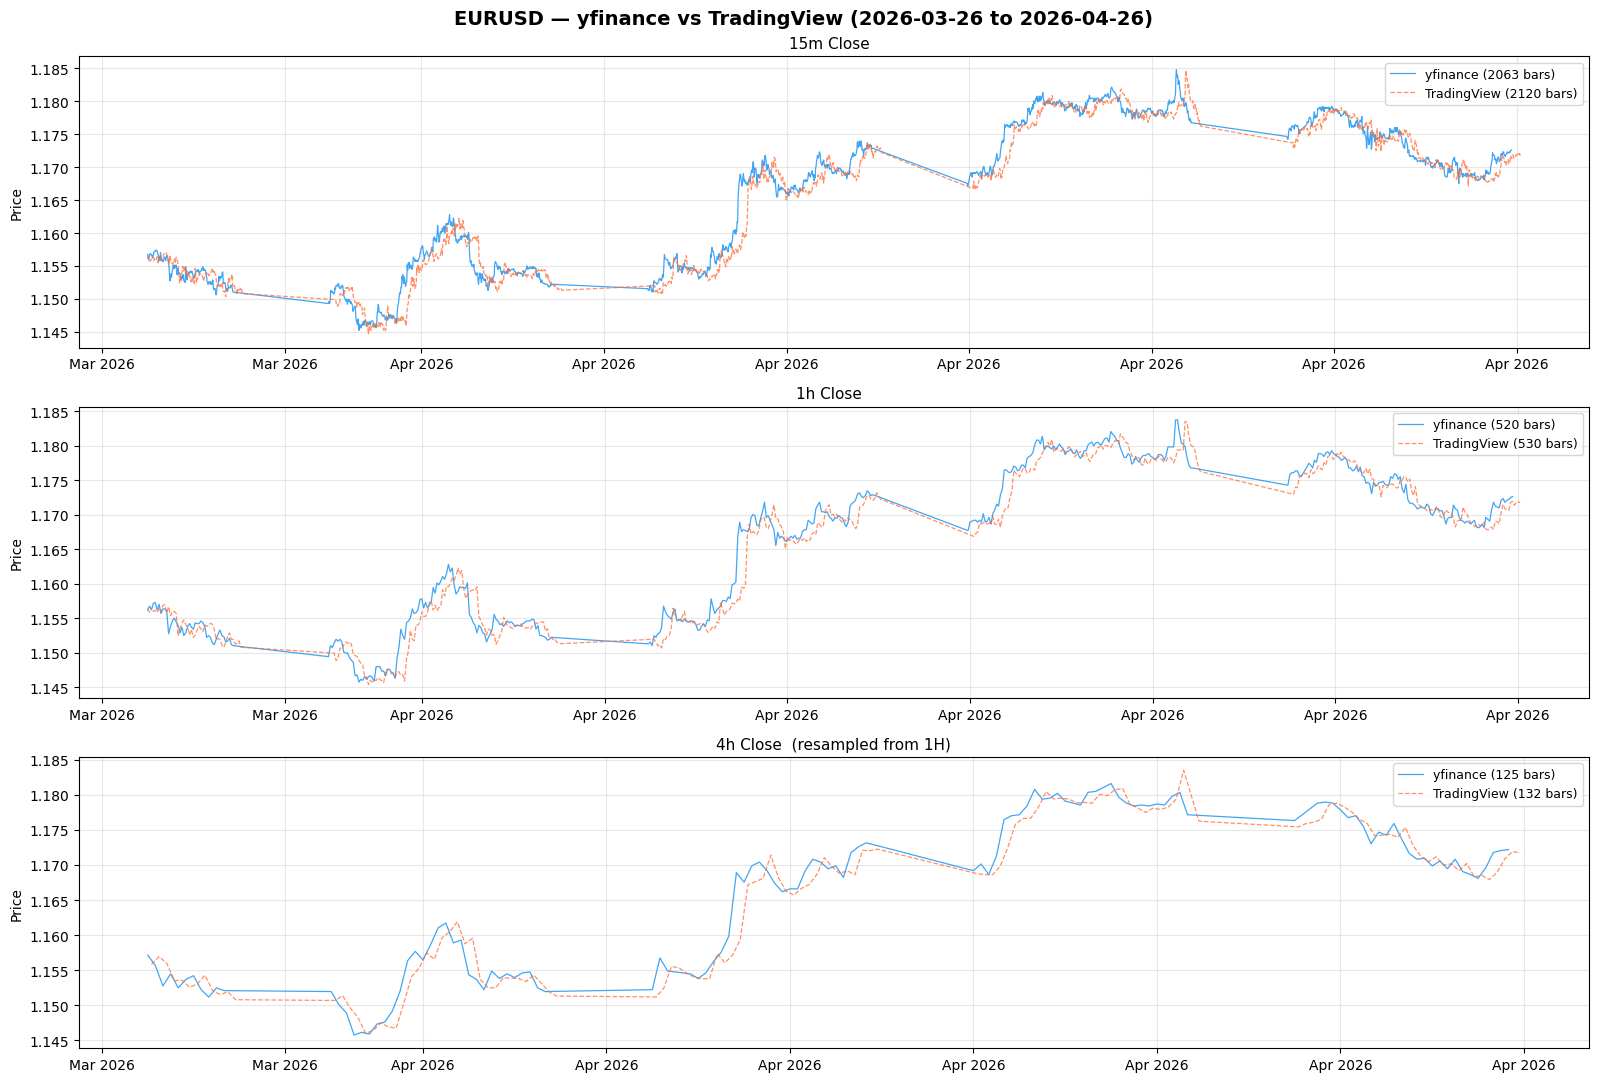

Chart saved → results/reports/01_yf_vs_tv_close.png


In [14]:
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=False)
fig.suptitle(
    f"{INSTRUMENT} — yfinance vs TradingView ({START_DATE} to {END_DATE})",
    fontsize=14, fontweight="bold"
)

for ax, tf in zip(axes, TIMEFRAMES):
    yf_df = yf_data.get(tf)
    tv_df = tv_data.get(tf)

    if yf_df is not None:
        ax.plot(yf_df.index, yf_df["close"],
                color="#2196F3", linewidth=0.9, alpha=0.85,
                label=f"yfinance ({len(yf_df)} bars)")
    if tv_df is not None:
        ax.plot(tv_df.index, tv_df["close"],
                color="#FF6B35", linewidth=0.9, alpha=0.75, linestyle="--",
                label=f"TradingView ({len(tv_df)} bars)")

    suffix = "(resampled from 1H)" if tf == "4h" else ""
    ax.set_title(f"{tf} Close  {suffix}", fontsize=11)
    ax.set_ylabel("Price")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()

out_dir = PROJECT_ROOT / "results" / "reports"
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "01_yf_vs_tv_close.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → results/reports/01_yf_vs_tv_close.png")

---
## 6. Cache File Verification

In [15]:
raw_dir    = PROJECT_ROOT / "data" / "raw"
cache_files = sorted(raw_dir.glob("*.csv"))

print(f"Files in data/raw/ ({len(cache_files)} found):")
print("-" * 65)
for f in cache_files:
    source_tag = "[yfinance]     " if "yfinance" in f.name else "[tradingview]  "
    size_kb    = f.stat().st_size / 1024
    print(f"  {source_tag} {f.name:<55}  {size_kb:>7.1f} KB")

yf_files = [f for f in cache_files if "yfinance"     in f.name]
tv_files = [f for f in cache_files if "tradingview"  in f.name]
print(f"\n  yfinance files     : {len(yf_files)}")
print(f"  tradingview files  : {len(tv_files)}")

# Cache filenames include source suffix — verify they're distinct
overlap = set(f.stem.replace('_yfinance','').replace('_tradingview','') for f in yf_files) & \
          set(f.stem.replace('_yfinance','').replace('_tradingview','') for f in tv_files)
print(f"  Shared instruments : {len(overlap)}  (expected — source suffix keeps them separate)")

Files in data/raw/ (9 found):
-----------------------------------------------------------------
  [tradingview]   EURUSD_15m_2026-03-26_2026-04-26.csv                       209.6 KB
  [tradingview]   EURUSD_15m_2026-03-26_2026-04-26_tradingview.csv           125.7 KB
  [yfinance]      EURUSD_15m_2026-03-26_2026-04-26_yfinance.csv              209.6 KB
  [tradingview]   EURUSD_1h_2026-03-26_2026-04-26.csv                         52.9 KB
  [tradingview]   EURUSD_1h_2026-03-26_2026-04-26_tradingview.csv             31.7 KB
  [yfinance]      EURUSD_1h_2026-03-26_2026-04-26_yfinance.csv                52.9 KB
  [tradingview]   EURUSD_4h_2026-03-26_2026-04-26.csv                         13.8 KB
  [tradingview]   EURUSD_4h_2026-03-26_2026-04-26_tradingview.csv              8.0 KB
  [yfinance]      EURUSD_4h_2026-03-26_2026-04-26_yfinance.csv                12.7 KB

  yfinance files     : 3
  tradingview files  : 3
  Shared instruments : 3  (expected — source suffix keeps them separate)


In [16]:
# Round-trip test — write → reload → compare values
print("Round-trip cache test:\n")

for source_label, data_dict in [("yfinance", yf_data), ("tradingview", tv_data)]:
    for tf, df_orig in data_dict.items():
        reload_fetcher = DataFetcher(
            instrument=INSTRUMENT,
            start=START_DATE,
            end=END_DATE,
            source=source_label,
            save_raw=False,
        )
        df_rel = reload_fetcher.fetch(tf)

        shape_ok  = df_orig.shape == df_rel.shape
        values_ok = (abs(df_orig["close"].values - df_rel["close"].values) < 1e-8).all() \
                    if shape_ok else False

        icon = "✓" if (shape_ok and values_ok) else "❌"
        print(f"  {icon} [{source_label}][{tf}]  shape={df_orig.shape}  "
              f"shape_match={shape_ok}  values_match={values_ok}")

2026-04-26 02:30:23,363 | INFO | DataFetcher ready — EURUSD | 2026-03-26 → 2026-04-26 | source=yfinance


Round-trip cache test:



2026-04-26 02:30:23,686 | INFO | [EURUSD][15m] Loaded from cache (2063 bars)
2026-04-26 02:30:23,702 | INFO | DataFetcher ready — EURUSD | 2026-03-26 → 2026-04-26 | source=yfinance
2026-04-26 02:30:23,788 | INFO | [EURUSD][1h] Loaded from cache (520 bars)
2026-04-26 02:30:23,802 | INFO | DataFetcher ready — EURUSD | 2026-03-26 → 2026-04-26 | source=yfinance
2026-04-26 02:30:23,849 | INFO | [EURUSD][4h] Loaded from cache (125 bars)
2026-04-26 02:30:23,864 | INFO | DataFetcher ready — EURUSD | 2026-03-26 → 2026-04-26 | source=tradingview


  ✓ [yfinance][15m]  shape=(2063, 5)  shape_match=True  values_match=True
  ✓ [yfinance][1h]  shape=(520, 5)  shape_match=True  values_match=True
  ✓ [yfinance][4h]  shape=(125, 5)  shape_match=True  values_match=True


2026-04-26 02:30:23,958 | INFO | [EURUSD][15m] Loaded from cache (2120 bars)
2026-04-26 02:30:23,977 | INFO | DataFetcher ready — EURUSD | 2026-03-26 → 2026-04-26 | source=tradingview
2026-04-26 02:30:24,028 | INFO | [EURUSD][1h] Loaded from cache (530 bars)
2026-04-26 02:30:24,055 | INFO | DataFetcher ready — EURUSD | 2026-03-26 → 2026-04-26 | source=tradingview
2026-04-26 02:30:24,092 | INFO | [EURUSD][4h] Loaded from cache (132 bars)


  ✓ [tradingview][15m]  shape=(2120, 5)  shape_match=True  values_match=True
  ✓ [tradingview][1h]  shape=(530, 5)  shape_match=True  values_match=True
  ✓ [tradingview][4h]  shape=(132, 5)  shape_match=True  values_match=True


---
## 7. Final Summary

In [17]:
REQUIRED_COLS = ["open", "high", "low", "close", "volume"]

def cols_ok(d): 
    return all(list(df.columns) == REQUIRED_COLS for df in d.values())

def no_nan(d):  
    return all(df[["open","high","low","close"]].isnull().sum().sum() == 0 for df in d.values())

def no_zero(d): 
    return all(len(df[(df["open"]==0)|(df["close"]==0)]) == 0 for df in d.values())

checks = [
    ("DataFetcher imports cleanly",                           True),
    ("yfinance — 3 timeframes fetched",                      all(tf in yf_data for tf in TIMEFRAMES)),
    ("yfinance — flat columns (multi_level_index=False)",    cols_ok(yf_data)),
    ("yfinance — no NaN in OHLC",                           no_nan(yf_data)),
    ("yfinance — no zero prices",                           no_zero(yf_data)),
    ("yfinance — 4H resampled from 1H (ratio ≈ 4)",         abs(len(yf_data['1h']) / max(len(yf_data['4h']),1) - 4) < 1),
    ("TradingView — 3 timeframes fetched",                   all(tf in tv_data for tf in TIMEFRAMES)),
    ("TradingView — flat columns",                           cols_ok(tv_data)),
    ("TradingView — no NaN in OHLC",                        no_nan(tv_data)),
    ("TradingView — no zero prices",                        no_zero(tv_data)),
    ("TradingView — 4H native (count within 5% of yf 4H)",  abs(len(tv_data['4h']) - len(yf_data['4h'])) / max(len(yf_data['4h']),1) < 0.05),
    ("Cache CSVs written for both sources",                  len(yf_files) > 0 and len(tv_files) > 0),
]

all_passed = True
print("╔══════════════════════════════════════════════════════════════╗")
print("║           DATA FETCHING VALIDATION — FINAL SUMMARY          ║")
print("╠══════════════════════════════════════════════════════════════╣")
for label, result in checks:
    icon = "✓" if result else "❌"
    if not result: all_passed = False
    print(f"║  {icon}  {label:<56} ║")
print("╠══════════════════════════════════════════════════════════════╣")
if all_passed:
    print("║  ✅ ALL CHECKS PASSED — ready for indicator pipeline        ║")
else:
    print("║  ⚠️  SOME CHECKS FAILED — review output above              ║")
print("╚══════════════════════════════════════════════════════════════╝")
print("\nNext step → notebooks/02_indicator_validation.ipynb")

╔══════════════════════════════════════════════════════════════╗
║           DATA FETCHING VALIDATION — FINAL SUMMARY          ║
╠══════════════════════════════════════════════════════════════╣
║  ✓  DataFetcher imports cleanly                              ║
║  ✓  yfinance — 3 timeframes fetched                          ║
║  ✓  yfinance — flat columns (multi_level_index=False)        ║
║  ✓  yfinance — no NaN in OHLC                                ║
║  ✓  yfinance — no zero prices                                ║
║  ✓  yfinance — 4H resampled from 1H (ratio ≈ 4)              ║
║  ✓  TradingView — 3 timeframes fetched                       ║
║  ✓  TradingView — flat columns                               ║
║  ✓  TradingView — no NaN in OHLC                             ║
║  ✓  TradingView — no zero prices                             ║
║  ❌  TradingView — 4H native (count within 5% of yf 4H)       ║
║  ✓  Cache CSVs written for both sources                      ║
╠═════════════════════════